# Lecture 12: Working with tabular data using `R` and `tidyverse`

Matthew Chan

To interactively work with the code below, open [lecture12.ipynb](./lecture12.ipynb) in VSCode. Make sure to select the `kernel` for `R` so that you can execute `R` code. You should have already set this up following the software installation instructions [here](../../software/README.md).

`R` is the second programming language after `Python` that we will learn in this course. We will use `R` over the next 5 lectures.

`R` is particularly well suited for reading, manipulating, and visualizing data in tabular and biological sequence formats. 
Many statistical tests are also available out of the box in `R`.

While "base" `R` is used widely, I almost exclusively use `R` for its two excellent package collections:

1. [Tidyverse](https://www.tidyverse.org/) - suited for tabular data
2. [Bioconductor](https://www.bioconductor.org/) - suited for biology-aware analyses

Today we will learn a few basic functions from `tidyverse` for working with tabular data.

Unlike `pandas` which is a single package with lot of functionality, `tidyverse` is a collection of packages that are focused on specific tasks.

1. [ggplot2](https://ggplot2.tidyverse.org/) - for plotting data
2. [dplyr](https://dplyr.tidyverse.org/) - for filtering, aggregating, and transforming data
3. [readr](https://readr.tidyverse.org/) - for reading and writing data
4. [tidyr](https://tidyr.tidyverse.org/) - for cleaning and transforming data
5. [stringr](https://stringr.tidyverse.org/) - for manipulating strings
6. [purrr](https://purrr.tidyverse.org/) - for manipulating lists of R objects
7. [forcats](https://forcats.tidyverse.org/) - for manipulating categorical data

You can load all the above packages in one go:

In [1]:
library(tidyverse)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.6     ✔ purrr   0.3.4
✔ tibble  3.1.7     ✔ dplyr   1.0.9
✔ tidyr   1.2.0     ✔ stringr 1.4.0
✔ readr   2.1.2     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()



# 1. First look into `R`

## Assigning variables

In `R`, the ` <- ` assignment operator is equivalent to the ` = ` assignment operator and can be used interchangeably. However, using the ` <- ` operator is more conventional.

## Import a dataset

In [2]:
data <- read_csv("data/penguins.csv")

Rows: 344 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): species, island, sex
dbl (6): rowid, bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Examine the imported dataset

Built-in functions for quickly examining a dataframe:
- `dim()`
- `str()`
- `summary()`
- `colnames()`
- `head()`
- `tail()`
- `View()`

In [5]:
head(data)

rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,Adelie,Torgersen,39.1,18.7,181,3750,male,2007
2,Adelie,Torgersen,39.5,17.4,186,3800,female,2007
3,Adelie,Torgersen,40.3,18.0,195,3250,female,2007
4,Adelie,Torgersen,NA,NA,NA,NA,NA,2007
5,Adelie,Torgersen,36.7,19.3,193,3450,female,2007
6,Adelie,Torgersen,39.3,20.6,190,3650,male,2007


## Plotting data

Below is an example how to plot the dataset. Think of the following: 
- What do you think each line of code is responsible for in the overall code cunk? 
- Can you see where the variables being called from the dataframe?
- Try to modify an aspect of the code chunk to produce a different plot. 


Warning message:
“Removed 2 rows containing non-finite values (stat_boxplot).”


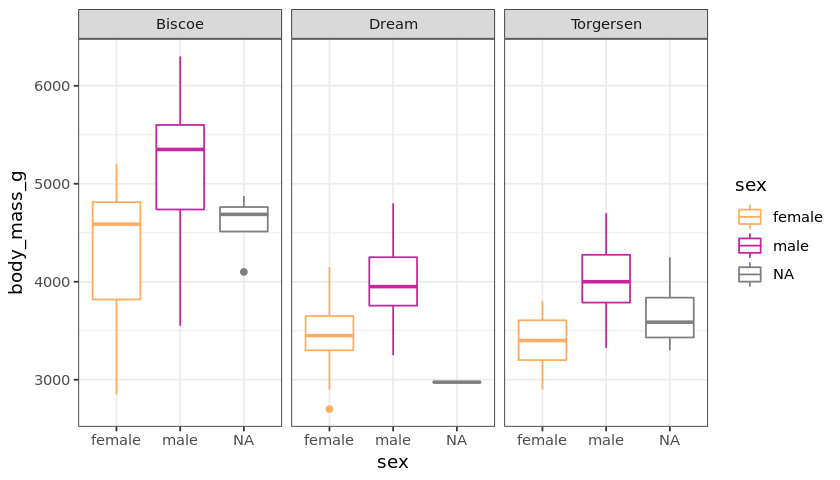

In [6]:
options(repr.plot.width = 7, repr.plot.height = 4)

ggplot(data) + 
    aes(x = sex, y = body_mass_g, color = sex) + 
    geom_boxplot() + 
    facet_wrap(~island) + 
    theme_bw() + 
    scale_color_manual(values = c("#fdae61", "#C625A1"))


# 2. `ggplot2` basics

## Reading data

Various options for reading and writing data are in package [`readr`](https://readr.tidyverse.org/).

In [7]:
data <- read_tsv("data/example_dataset_1.tsv")

data

Rows: 16 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): strain, insert_sequence, kozak_region
dbl (4): mean_yfp, mean_rfp, mean_ratio, se_ratio

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


strain,mean_yfp,mean_rfp,mean_ratio,se_ratio,insert_sequence,kozak_region
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
schp688,1748,20754,0.755,0.066,10×AGA,A
schp684,3294,20585,1.437,0.021,10×AGA,B
schp690,3535,20593,1.541,0.018,10×AGA,C
schp687,4658,20860,2.004,0.021,10×AGA,D
schp686,5000,21171,2.121,0.023,10×AGA,E
schp685,7379,22956,2.893,0.050,10×AGA,F
schp683,9365,23866,3.522,0.110,10×AGA,G
schp689,8693,22649,3.424,0.125,10×AGA,H
schp679,2528,19906,1.149,0.056,10×AAG,A


The tabular data structure is called a `tibble` in `tidyverse`, and is a souped-up version of the [data.frame](https://en.wikipedia.org/wiki/Data_frame) R data structure with additional nice features.


## Plotting data

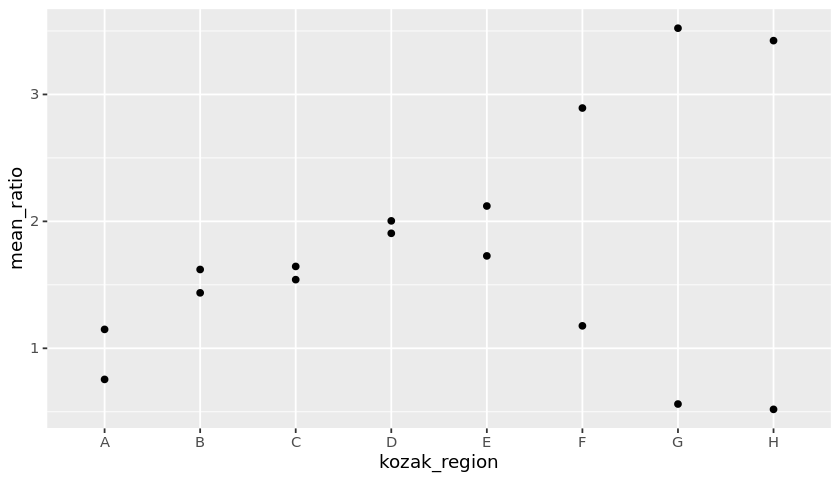

In [8]:
ggplot(data) + aes(x = kozak_region, y = mean_ratio) +
  geom_point()


**Anatomy of a `ggplot2` plot:** 

`ggplot(tibble) + aes(x = x_axis) + geom_plot_type() + layers...`

 - Begins with `ggplot` function with a `tibble` argument as the first argument.
 - `aes` specifies the variables to plot.
 - `geom` specifies the type of plot.
 - `+` adds additional `layers` to the plot.


**Key differences with `Python`**
  - No need to specify variables within quotes.
  - Indentation convention is different.

## Change size of plot globally

In [ ]:
options(repr.plot.width = 5, repr.plot.height = 3)

## How do we show multiple experimental variables?


Plotting a point graph with `color`

In [ ]:
ggplot(data) + 
    aes(x = kozak_region, y = mean_ratio, color = insert_sequence) +
    geom_point()

Plotting a line graph

In [ ]:
ggplot(data) + 
    aes(x = kozak_region, y = mean_ratio, color = insert_sequence, group = insert_sequence) +
    geom_line()

Plotting point and line graphs

In [ ]:
ggplot(data) + 
    aes(x = kozak_region, y = mean_ratio, color = insert_sequence, group = insert_sequence) +
    geom_line() + 
    geom_point()

## ‘Faceting’ – Plotting in multiple panels

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 3)

ggplot(data) + 
    aes(x = kozak_region, y = mean_ratio, color = insert_sequence, group = insert_sequence) +
    geom_line() + 
    geom_point() + 
    facet_grid(~ insert_sequence)

---

# 3. In-class `ggplot2` exercises

(20 min)

## 1. Make X, Y, legend labels into nice strings

See https://ggplot2.tidyverse.org/reference/labs.html

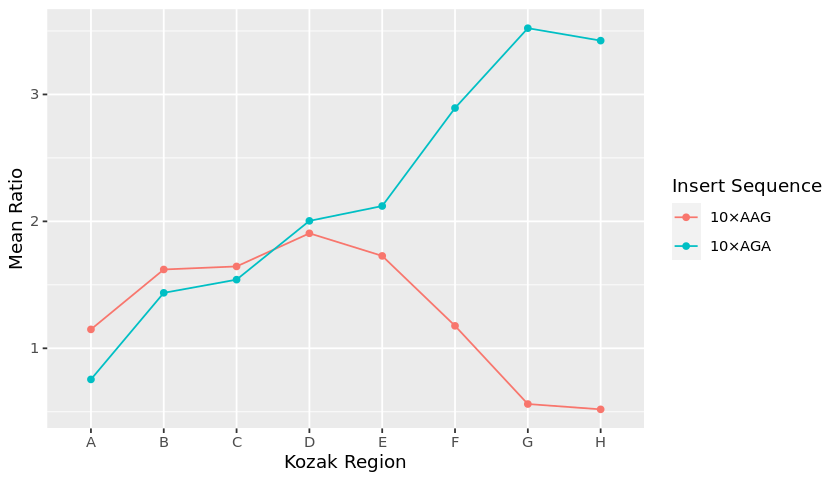

In [40]:
ggplot(data, aes(x = kozak_region,
                 y = mean_ratio,
                 color = insert_sequence,
                 group = insert_sequence)) +
  geom_line() +
  geom_point() +
  labs(x = "Kozak Region", y = "Mean Ratio", color = "Insert Sequence") 


## 2. Add title to the above plot

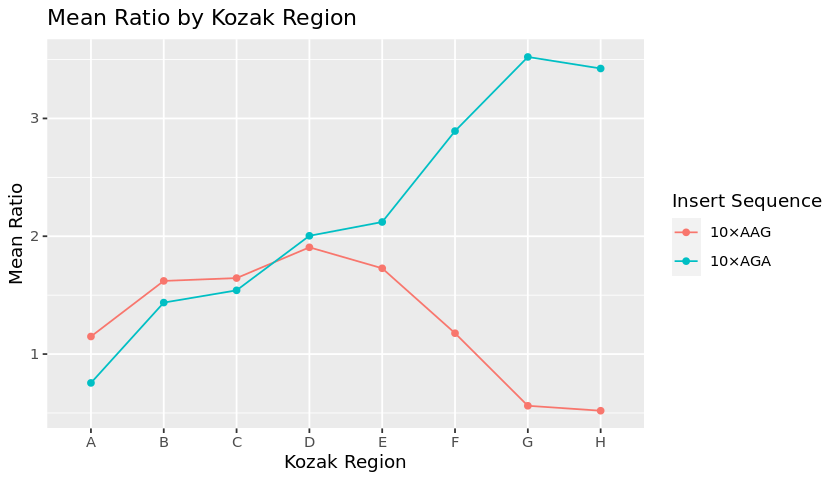

In [41]:
ggplot(data, aes(x = kozak_region,
                 y = mean_ratio,
                 color = insert_sequence,
                 group = insert_sequence)) +
  geom_line() +
  geom_point() +
  labs(x = "Kozak Region", y = "Mean Ratio", color = "Insert Sequence") + 
  ggtitle("Mean Ratio by Kozak Region")

## 3. Change the plot look to a `classic` theme

See https://ggplot2.tidyverse.org/reference/ggtheme.html

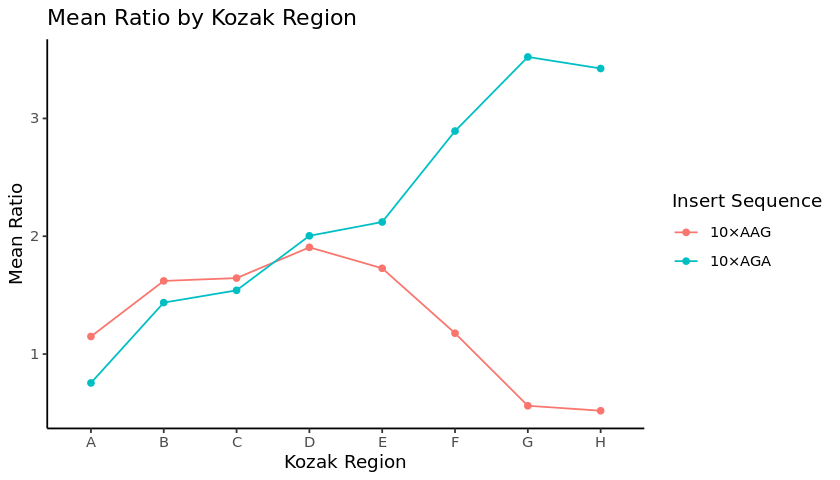

In [42]:
ggplot(data, aes(x = kozak_region,
                 y = mean_ratio,
                 color = insert_sequence,
                 group = insert_sequence)) +
  geom_line() +
  geom_point() +
  labs(x = "Kozak Region", y = "Mean Ratio", color = "Insert Sequence") + 
  ggtitle("Mean Ratio by Kozak Region") +
  theme_classic()
  


## 4. Change Y axis to log scale

See https://ggplot2.tidyverse.org/reference/scale_continuous.html

In [ ]:
ggplot(data, aes(x = kozak_region,
                 y = mean_ratio,
                 color = insert_sequence,
                 group = insert_sequence)) +
  geom_line() +
  geom_point() +
  labs(x = "Kozak Region", y = "Mean Ratio", color = "Insert Sequence") + 
  ggtitle("Mean Ratio by Kozak Region") +
  theme_classic()
  

## 5. Change Y scale to go linearly from 0 to 5

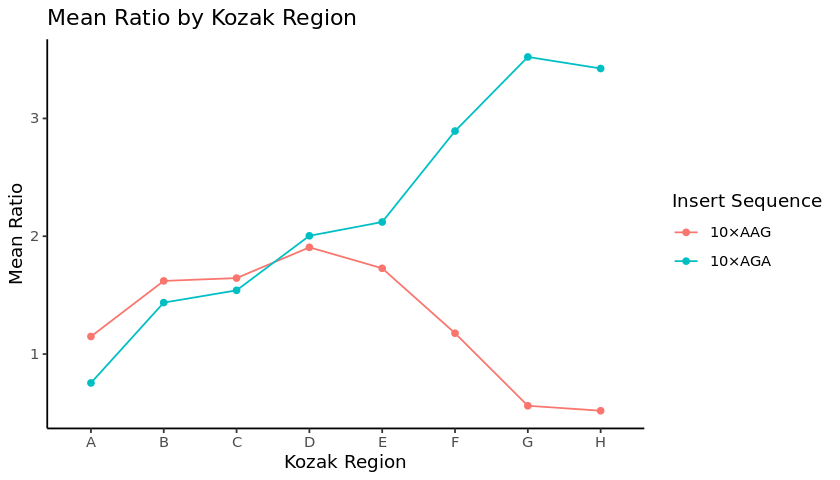

In [46]:
ggplot(data, aes(x = kozak_region,
                 y = mean_ratio,
                 color = insert_sequence,
                 group = insert_sequence)) +
  geom_line() +
  geom_point() +
  labs(x = "Kozak Region", y = "Mean Ratio", color = "Insert Sequence") + 
  ggtitle("Mean Ratio by Kozak Region") +
  theme_classic()
  

---

# 4. Transforming data

Uses functions from the [`dplyr`](https://dplyr.tidyverse.org/) package.

In [47]:
data <- read_tsv("data/example_dataset_1.tsv")


data

Rows: 16 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): strain, insert_sequence, kozak_region
dbl (4): mean_yfp, mean_rfp, mean_ratio, se_ratio

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


strain,mean_yfp,mean_rfp,mean_ratio,se_ratio,insert_sequence,kozak_region
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
schp688,1748,20754,0.755,0.066,10×AGA,A
schp684,3294,20585,1.437,0.021,10×AGA,B
schp690,3535,20593,1.541,0.018,10×AGA,C
schp687,4658,20860,2.004,0.021,10×AGA,D
schp686,5000,21171,2.121,0.023,10×AGA,E
schp685,7379,22956,2.893,0.050,10×AGA,F
schp683,9365,23866,3.522,0.110,10×AGA,G
schp689,8693,22649,3.424,0.125,10×AGA,H
schp679,2528,19906,1.149,0.056,10×AAG,A


## Select specific columns

In [48]:
select(data, strain, mean_ratio, insert_sequence, kozak_region)

strain,mean_ratio,insert_sequence,kozak_region
<chr>,<dbl>,<chr>,<chr>
schp688,0.755,10×AGA,A
schp684,1.437,10×AGA,B
schp690,1.541,10×AGA,C
schp687,2.004,10×AGA,D
schp686,2.121,10×AGA,E
schp685,2.893,10×AGA,F
schp683,3.522,10×AGA,G
schp689,3.424,10×AGA,H
schp679,1.149,10×AAG,A


## Filter rows

In [ ]:
data <- read_tsv("data/example_dataset_1.tsv") %>%
    print()

In [ ]:
data %>% 
  filter(kozak_region == "A")

In [ ]:
data %>%
  filter(kozak_region == "A", insert_sequence == "10×AGA")

## Combine operations using the ` %>% ` operator

In [ ]:
data <- read_tsv("data/example_dataset_1.tsv") %>% 
  select(strain, mean_ratio, insert_sequence, kozak_region)

Above is the same as the following:

In [ ]:
data <- read_tsv("data/example_dataset_1.tsv") %>% 
  select(., strain, mean_ratio, insert_sequence, kozak_region)

The `%>%` operator lets you `chain` different data analysis tasks together and makes the analysis logic easier to understand.


_Side note: You can create keyboard shortcuts for ` <- ` and ` %>% ` in VSCode as explained [here](https://code.visualstudio.com/docs/getstarted/keybindings)._

Rasi uses `Alt + -` for ` <- ` and `Alt + Shift + m` for ` %>% ` following `RStudio` convention.

You can get a view of the transformed data using `print()` as the last step in a chain of commands

In [ ]:
data <- read_tsv("data/example_dataset_1.tsv") %>% 
  select(strain, mean_ratio, insert_sequence, kozak_region) %>% 
  print() 

In [ ]:
data %>%
  filter(kozak_region == "A") %>% 
  select(strain, mean_ratio, insert_sequence, kozak_region)

## Arrange (sort) rows in a specific order

In [ ]:
data %>%
  arrange(mean_ratio)

## Create new columns using `mutate`

In [ ]:
data <- read_tsv("data/example_dataset_2.tsv") %>% 
  print()

In [ ]:
data <- data %>%
  mutate(mean_ratio = mean_yfp / mean_rfp) %>%
  print()

Use mutate to modify existing columns

In [ ]:
data %>%
  mutate(mean_ratio = round(mean_ratio, 2))

## Combine tables using `join` functions

Variants: `inner_join`, `left_join`, `right_join`, `full_join`

See [https://dplyr.tidyverse.org/reference/mutate-joins.html](https://dplyr.tidyverse.org/reference/mutate-joins.html)

In [ ]:
annotations <- read_tsv("data/example_dataset_3.tsv")

annotations

In [ ]:
data %>% 
  inner_join(annotations, by = "strain")

In [ ]:
data %>% 
  left_join(annotations, by = "strain")

In [ ]:
data %>% 
  right_join(annotations, by = "strain")

## You can combine `dplyr` and `ggplot2` functions

But remember to use ` %>% ` in `dplyr` vs ` +` in `ggplot2`!

In [ ]:
data %>% 
  mutate(mean_ratio = mean_yfp / mean_rfp) %>%
  left_join(annotations, by = "strain") %>%
  ggplot(aes(x = kozak_region, y = mean_ratio, 
             color = insert_sequence, group = insert_sequence)) +
  geom_line() +
  geom_point()

## Use `stringr` functions to manipulate string columns

All functions are named nicely and begin with `str_`.

See [https://stringr.tidyverse.org/reference/index.html](https://stringr.tidyverse.org/reference/index.html)

In [ ]:
data %>% 
  mutate(mean_ratio = mean_yfp / mean_rfp) %>%
  left_join(annotations, by = "strain") %>% 
  mutate(codon = str_extract(insert_sequence, "[A-Z]{3}$"))

---

# 5. In-class data transformation exercises

(20 min)

## 1. Create log2-transformed YFP/RFP ratio as a new column

Google for `log2 R` to find the appropriate function

In [ ]:
data <- read_tsv("data/example_dataset_2.tsv")

## 2. Extract strain number from the `strain` column into a new column and sort numerically by strain number

Extract the strain number using a `stringr` function.

Google for `character to integer R` to find appropriate function to use in `mutate`.

Then sort.

In [ ]:
annotations <- read_tsv("data/example_dataset_3.tsv")

annotations

## 3. Plot with the X axis as `kozak_region` but sorted by strain number

This requires a bit more reading and discussion, but it is a good example of how to learn new `tidyverse` functions on your own!

Use [fct_reorder](https://forcats.tidyverse.org/reference/fct_reorder.html) function from the [`forcats`](https://forcats.tidyverse.org/reference/index.html) package to sort `kozak_region` by strain number you created above in a `mutate` step and then feed it into `ggplot`.

In [ ]:
data %>% 
  mutate(mean_ratio = mean_yfp / mean_rfp) %>%
  left_join(annotations, by = "strain") %>%
  ggplot(aes(x = kozak_region, y = mean_ratio, 
             color = insert_sequence, group = insert_sequence)) +
  geom_line() +
  geom_point()

---

# 6. Grouping, summarizing, and reshaping data

## Use `summarize` to calculate stats across rows

In [ ]:
data <- read_tsv("data/example_dataset_2.tsv")

In [ ]:
data %>%
  summarize(max_yfp = max(mean_yfp),
            max_rfp = max(mean_rfp)) %>%
  print()

## Other examples of summary functions:

- `min()`
- `mean()`
- `sd()`	
- `dplyr::first()`
- `dplyr::n()`

## Use `group_by` to group rows by one or more columns

In [ ]:
data <- read_tsv("data/example_dataset_4.tsv") %>% 
  print()

In [ ]:
data %>% 
  group_by(strain) %>%
  print()

## Use `group_by` + `summarize` for statistics by group

In [ ]:
data %>% 
  group_by(strain) %>%
  summarize(mean_yfp = mean(yfp), mean_rfp = mean(rfp)) %>%
  print()

In [ ]:
data %>% 
  group_by(strain) %>%
  summarize(mean_yfp = mean(yfp), mean_rfp = mean(rfp),
            se_yfp = sd(yfp) / sqrt(n()), 
            se_rfp = sd(rfp) / sqrt(n())) %>%
  print()

## `%>%` enables complex yet easily understandable data analysis pipelines

In [ ]:
annotations <- read_tsv("data/example_dataset_3.tsv")

annotations

In [ ]:
data %>% 
  group_by(strain) %>%
  summarize(mean_yfp = mean(yfp), mean_rfp = mean(rfp)) %>%
  mutate(mean_ratio = mean_yfp / mean_rfp) %>%
  left_join(annotations, by = "strain") %>%
  print()

## `%>%` and `+` if you want to plot


In [ ]:
options(repr.plot.width = 5, repr.plot.height = 3)

data %>% 
  group_by(strain) %>%
  summarize(mean_yfp = mean(yfp), mean_rfp = mean(rfp)) %>%
  mutate(mean_ratio = mean_yfp / mean_rfp) %>%
  left_join(annotations, by = "strain") %>%
  ggplot(aes(x = kozak_region, y = mean_ratio, 
             color = insert_sequence, group = insert_sequence)) +
  geom_line() + 
  geom_point() +
  theme_classic() +
  labs(x = "Kozak region", y = "Mean YFP / RFP ratio", color = "Insert")

## Re-shape data using `pivot_longer` and `pivot_wider`

In [ ]:
data <- read_tsv("data/example_dataset_4.tsv") %>% 
  print()

How do you plot a histogram of both `yfp` and `rfp` as separate panels?

In [ ]:
data %>%
  pivot_longer(c("yfp", "rfp"), names_to = "channel", values_to = "value") %>%
  print()

In [ ]:
data %>%
  pivot_longer(c("yfp", "rfp"), names_to = "channel", values_to = "value") %>%
  pivot_wider(names_from = "channel", values_from = "value") %>%
  print()

`pivot_longer` is useful for handling distinct measurements without listing them explicitly.

In [ ]:
plot_data <- data %>%
  pivot_longer(c("yfp", "rfp"), names_to = "channel", values_to = "value")

plot_data %>%
  ggplot(aes(x = value)) +
  facet_wrap(~ channel) +
  geom_histogram(bins = 30) +
  theme_bw()


## Use `purrr::map` and `purrr::unnest` to read and work with tables from many files

We use `list.files` and `enframe` to go from a list of files to a `tibble` quickly. Also check out `deframe`.

In [ ]:
data <- list.files("data/channel_data/", full.names = T) %>%
  enframe("number", "file") %>%
  mutate(data = map(file, read_tsv)) %>%
  unnest(data) %>%
  mutate(channel = str_extract(file, "[^/]+(?=.tsv)")) %>%
  select(-number, -file) %>%
  print()

# 7. In-class exercises

(20 min)

## 1. Re-shape data read above from two separate files to create columns for `yfp` and `rfp`

## 2. Calculate ratio of YFP to RFP

## 3. Calculate the `mean` and `standard error` of the ratio between replicates

## 4. Combine data with annotations

## 5. Plot the mean and standard deviation of the YFP-RFP ratio as a function of the Kozak region.

Hint: You have to use `geom_errorbar()` in addition to `geom_point()` and `geom_line()`.